# Description
Calculation of the number of passes using real breadcrumbs. Finished on May 18th, 2026. It is the first version it can count by boundary cell. The grid is done by rectangles

In [425]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [426]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.geometry import LineString, Point
from shapely.affinity import rotate
import numpy as np
import pandas as pd
import geopandas as gpd
import warnings
from inc import *
from shapely.ops import polygonize, unary_union

# Configuration

In [427]:
tol_deg  = 5
street_length = 10
sampling_distance = 10
dx = 0.5         # Thickness of each vertical bar
d_angles = -10 * np.ones(len(np.arange(0, 181, 10)))  # 10 degree rotation steps from 0 to 360 inclusive

# Query the surveys

In [428]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[200]].copy()
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

l = 0
surveys = segments['SurveyId'].unique()
#survey = segments[segments['SurveyId'] == surveys[l]]
survey = segments
survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)
survey_gdf = gpd.GeoDataFrame(survey, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)

# Algorithm starts here
## Prepare the surveys

In [429]:
# Compute the union of the survey geometries and simplify the result
#survey_union = survey_gdf.unary_union.simplify(10)  # Adjust tolerance 1.0 as needed
survey_union = survey_gdf.unary_union  # Adjust tolerance 1.0 as needed

# Create a GeoDataFrame from the union
survey_union_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union]},
    crs=survey_gdf.crs
)

# Make an offset of 10 (buffer by 10 units)
survey_union_offset_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union.buffer(street_length/2, cap_style=2)]},
    crs=survey_gdf.crs,
    geometry='geometry'
)

In [430]:
# Get the center as the midpoint of the bounds (average of min/max x/y)
minx, miny, maxx, maxy = survey_union_offset_gdf.total_bounds
center = Point((minx + maxx) / 2, (miny + maxy) / 2)
print("Center of the bounds:", center)

# Shift the survey_union_offset_gdf geometry so that the centroid is at (0, 0)
survey_union_offset_gdf['geometry'] = survey_union_offset_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)

Center of the bounds: POINT (304222.42681 5733916.494905001)


In [431]:
survey_gdf['geometry'] = survey_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)
survey_gdf.set_geometry('geometry', inplace=True)


/tmp/ipykernel_272755/3853611118.py:4: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


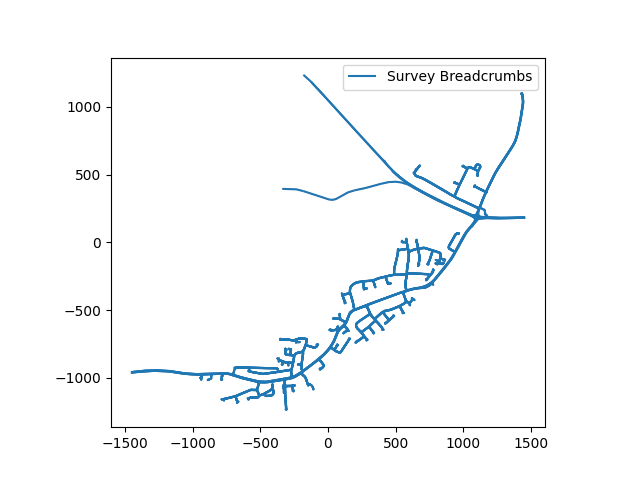

In [432]:
fig,ax = plt.subplots()
survey_gdf.plot(ax=ax, label='Survey Breadcrumbs')
survey_union_offset_gdf.plot(ax=ax, color='red', alpha=0.5, label='Street')
ax.legend()

In [433]:
center.x

304222.42681

# Generate the grid

In [434]:
# Assuming 'angle' and 'intersection_gdf' are in scope
def points_and_rotate(bottom, rot_angle):
    # Convert to Point, rotate each, and return as two tuples
    if isinstance(bottom, list) and all(isinstance(pt, tuple) and len(pt) == 2 for pt in bottom):
        rotated = [rotate(Point(pt), angle=rot_angle, origin=(0, 0)) for pt in bottom]
        if len(rotated) == 2:
            return (tuple(rotated[0].coords[0]), tuple(rotated[1].coords[0]))
    return (None, None)



In [435]:
import time
from shapely.geometry import MultiPoint

def get_max_min_points(df):
   min_x, min_y, max_x, max_y = MultiPoint(list(df['geometry'])).bounds
   return max_y - min_y

def get_nop(df):
    return df.shape[0]

start = time.perf_counter()
output_gdf = gpd.GeoDataFrame()
cumulative = 0
angle = 0
bounds = survey_union_offset_gdf.total_bounds
min_x, min_y, max_x, max_y = map(float, bounds)  # Ensure cast to float
r_x = np.sqrt(max_x**2 + max_y**2)
r_y = np.sqrt(min_x**2 + min_y**2)

# Compute number of columns safely and cast to int
num_cols = int(np.floor((2*r_x) / sampling_distance)) + 1

# Compute bar center x-positions
x_centers = np.linspace(-r_x, r_x, num=num_cols)

# For each center, form a thin rectangle
grid_lines = [
Polygon([
    (x - dx/2, r_y),
    (x + dx/2, r_y),
    (x + dx/2, -r_x),
    (x - dx/2, -r_x)
])
for x in x_centers
]
# Define the vector
vec = np.array([1,0])
ortho_vec = np.array([0,1])
grid_lines_gdf = gpd.GeoDataFrame({'geometry': grid_lines}, crs=survey_gdf.crs, geometry='geometry')
grid_lines_gdf['grid_idx'] = grid_lines_gdf.index
init_time = time.perf_counter()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    current_vec = vec   
    current_ortho_vec = ortho_vec
    for d_angle in d_angles:
            print('Processing angle: ', angle)
            # Rotate the map
            start_rotate = time.perf_counter()
            if angle == 0:
                contour_gdf = survey_union_offset_gdf.copy()
                survey_rotated_gdf = survey_gdf.copy()
            else:
                contour_gdf['geometry'] = contour_gdf['geometry'].rotate(angle=-d_angle, origin=(0,0))
                survey_rotated_gdf['geometry'] = survey_rotated_gdf['geometry'].rotate(angle=-d_angle, origin=(0,0))

            end_rotate = time.perf_counter()
            print(f'Time to rotate: {end_rotate - start_rotate}')

            #Create the intersection of the grid with the survey offset
            intersection_gdf = gpd.overlay(
                grid_lines_gdf, 
                contour_gdf, 
                how='intersection', 
                keep_geom_type=False
            )    
            
            intersection_gdf = intersection_gdf.explode(index_parts=True)
            intersection_gdf.reset_index(drop=True, inplace=True)
            intersection_gdf.set_geometry('geometry', inplace=True)
            intersection_gdf.to_crs(survey_gdf.crs, inplace=True)
            end_intersection = time.perf_counter()
            print(f'Time to intersection: {end_intersection - end_rotate}')

            start_bottom = time.perf_counter()
            intersection_gdf['bottom_points'] = intersection_gdf['geometry'].apply(lambda geom: get_bottom_two_points(geom,angle,rotattion = False))

            # Get the unit vector along the [1,0] direction or the rotated version
            intersection_gdf['unit_vector'] = intersection_gdf['bottom_points'].apply(safe_unit_vector)

            # Get teh angle between the unit vector and the rotated vector
            intersection_gdf['angle_measured'] = intersection_gdf['unit_vector'].apply(lambda vec: angle_between_vectors(vec,rotated_vec=[1,0]))
            intersection_gdf['angle_rotated'] = angle
            end_angle = time.perf_counter()
            print(f'Time to angle: {end_angle - start_bottom}')

            # Get only those lines which are aligned with the rotated vector
            right_angles = intersection_gdf[np.isclose(intersection_gdf['angle_measured'], 0, atol=tol_deg)]

            right_angles['cell_boundary'] = right_angles.apply(lambda row: get_central_line_vertical(row), axis=1)
            right_angles['cell_boundary_length'] = right_angles['cell_boundary'].apply(lambda line: line.length)
            #mean_cell_boundary_length = right_angles['cell_boundary_length'].mean()
            #std_cell_boundary_length = right_angles['cell_boundary_length'].std()
            #right_angles = right_angles[np.isclose(right_angles['cell_boundary_length'], 12.7, atol=2*.9)]
            right_angles['grid_boundary'] = right_angles['geometry']
            right_angles['geometry'] = right_angles['cell_boundary']
            right_angles = right_angles.set_geometry('geometry')
            right_angles = right_angles.set_crs(utm_crs)
            right_angles['cell_idx'] = right_angles.index

            #Intersection of the boundaries with the surveys
            intersection_survey_gdf = gpd.overlay(right_angles, survey_rotated_gdf[['Order','geometry']], how='intersection', keep_geom_type=False)
            intersection_survey_gdf = intersection_survey_gdf.explode(index_parts=True)
            intersection_survey_gdf = intersection_survey_gdf[['Order','geometry']]

            intersection_survey_gdf = intersection_survey_gdf.reset_index(drop=True)
            intersection_survey_gdf = intersection_survey_gdf.set_geometry('geometry')
            intersection_survey_gdf = intersection_survey_gdf.set_crs(utm_crs)

            #Join the boundaries with the surveys intersection
            start_join = time.perf_counter()

            r = right_angles.copy()
            r['geometry'] = r['cell_boundary']
            r.drop(columns = ['cell_boundary','grid_boundary'], inplace=True)
            r = r.set_geometry('geometry')
            r = r.set_crs(utm_crs)
            joined = gpd.sjoin(r, intersection_survey_gdf, how='right', predicate='intersects')

            spread = joined.groupby('cell_idx').apply(lambda x: get_max_min_points(x))
            nop = joined.groupby('cell_idx').apply(lambda x: get_nop(x))
            spread_df = spread.reset_index()
            spread_df.rename(columns = {0:'spread'}, inplace=True)
            nop_df = nop.reset_index()
            nop_df.rename(columns = {0:'nop'}, inplace=True)
            result = pd.merge(spread_df, nop_df, on = 'cell_idx', how = 'left')
            r = pd.merge(r, result, on = 'cell_idx', how = 'left')
            stop_join = time.perf_counter()
            print(f'Time to join: {stop_join - start_join}')
            #filtered = right_angles[(right_angles['cell_boundary_length'] < 2*street_length)]
            output_gdf = pd.concat([output_gdf, r])
        
            #output_gdf = output_gdf[(output_gdf['spread'] < street_length + 3*std_spread) & (output_gdf['cell_boundary_length'] < street_length + 3*std_len)]
            angle = angle + d_angle



Processing angle:  0
Time to rotate: 0.0038830620469525456
Time to intersection: 0.37324577500112355


Time to angle: 0.30756534199463204
Time to join: 0.9126205450156704
Processing angle:  -10.0
Time to rotate: 0.11763186700409278
Time to intersection: 0.37851463694823906
Time to angle: 0.29016169800888747
Time to join: 0.2734910150174983
Processing angle:  -20.0
Time to rotate: 0.10273197101196274
Time to intersection: 0.35736146301496774
Time to angle: 0.37182079296326265
Time to join: 0.4344340679817833
Processing angle:  -30.0
Time to rotate: 0.10195691499393433
Time to intersection: 0.277327960007824
Time to angle: 0.30669896298786625
Time to join: 0.3957183510065079
Processing angle:  -40.0
Time to rotate: 0.08193327696062624
Time to intersection: 0.37280157301574945
Time to angle: 0.2039912220207043
Time to join: 0.18710292998002842
Processing angle:  -50.0
Time to rotate: 0.12093999102944508
Time to intersection: 0.2871657540090382
Time to angle: 0.2539673509891145
Time to join: 0.3629364339867607
Processing angle:  -60.0
Time to rotate: 0.08217975898878649
Time to intersection

In [436]:
output_gdf['diff'] = (output_gdf['cell_boundary_length'] - output_gdf['spread'])/street_length
print(output_gdf.shape[0])
output_gdf_no_nan_spread = output_gdf[~output_gdf['nop'].isna()]
print(output_gdf_no_nan_spread.shape[0])
output_gdf_short = output_gdf_no_nan_spread.copy()
#output_gdf_short = output_gdf_no_nan_spread[output_gdf_no_nan_spread['cell_boundary_length'] < 2*street_length]
print(output_gdf_short.shape[0])
#output_gdf_long = output_gdf_short[(output_gdf_short['diff'] >= 1)&(output_gdf_short['diff']  <= 1.06)]
#print(output_gdf_long.shape[0])


1933
1909
1909


In [439]:
# Group by angle_rotated, rotate geometry to -angle_rotated, and display result
from shapely import affinity

def rotate_geom_fixed(geom, angle_deg):
    """Rotate geometry -angle_deg degrees about (0,0) if supported, else return as-is."""
    # Only rotate if geometry supports it
    return affinity.rotate(geom, angle_deg, origin=(0, 0))

rotated_by_angle = []

for angle, group in output_gdf_short.groupby('angle_rotated'):
    rotated_group = group.copy()
    # Apply safe rotation for each geometry in the group (rotate to -angle_rotated) using affinity.rotate
    rotated_group['geometry'] = rotated_group.apply(
        lambda row: rotate_geom_fixed(row.geometry, row['angle_rotated']), axis=1
    )
    rotated_by_angle.append(rotated_group)

rotated_output_gdf = pd.concat(rotated_by_angle).reset_index(drop=True)

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:130: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)
/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:130: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)
/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:130: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)
/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:130: Shape

In [440]:
overlapped = gpd.sjoin(rotated_output_gdf, rotated_output_gdf, how = 'inner', predicate = 'intersects')
overlapped = overlapped[overlapped.index != overlapped.index_right].copy()
overlapped = overlapped.reset_index()

overlapped = overlapped[['index','index_right','cell_boundary_length_left']]
indx_to_remove = []

while (len(overlapped) > 0):
    overlapped_summary = overlapped.groupby('index').agg({'cell_boundary_length_left':'mean','index_right':'nunique'}).sort_values(by = 'index_right', ascending = False)
    idx_intersection = overlapped_summary['index_right'].idxmax()
    max_intersections = overlapped_summary['index_right'].max()
    if max_intersections == 1:
        idx_remove = overlapped_summary['cell_boundary_length_left'].idxmax()
        max_remove = overlapped_summary['cell_boundary_length_left'].max()
    else:
        idx_remove = idx_intersection
        max_remove = max_intersections
    overlapped = overlapped[overlapped['index'] != idx_remove]
    overlapped = overlapped[overlapped['index_right'] != idx_remove]
    indx_to_remove.append(idx_remove)
print(indx_to_remove)

[996, 1097, 1080, 1115, 1330, 1055, 845, 1349, 1078, 1326, 303, 1116, 1597, 1332, 1001, 1006, 748, 744, 501, 1111, 428, 1524, 465, 91, 1039, 497, 1304, 602, 1127, 1207, 1183, 382, 1147, 887, 1148, 1032, 1696, 447, 1844, 991, 881, 571, 1401, 163, 1179, 1672, 183, 675, 883, 250, 301, 153, 666, 2, 793, 1465, 1156, 1066, 1190, 1333, 1007, 813, 1159, 1379, 1751, 438, 478, 528, 1497, 1794, 118, 81, 1306, 168, 654, 1213, 1688, 100, 1746, 414, 817, 928, 589, 337, 595, 1411, 1677, 1398, 1418, 601, 1327, 1310, 522, 1021, 1837, 513, 502, 516, 1475, 1185, 859, 853, 216, 857, 1556, 1648, 535, 689, 1874, 1089, 1193, 349, 1480, 1385, 1025, 1195, 672, 34, 1851, 515, 1076, 1391, 1077, 983, 274, 1043, 980, 1393, 473, 1029, 1409, 955, 468, 1013, 1000, 1402, 1383, 846, 690, 1405, 1158, 1562, 75, 1302, 1210, 1189, 1197, 1083, 1206, 794, 353, 1350, 1114, 176, 29, 625, 1880, 622, 548, 241, 330, 1553, 1812, 1399, 1308, 1166, 1303, 1388, 1563, 482, 1858, 920, 539, 863, 1202, 750, 1561, 251, 1684, 1381, 68, 439

<Axes: >

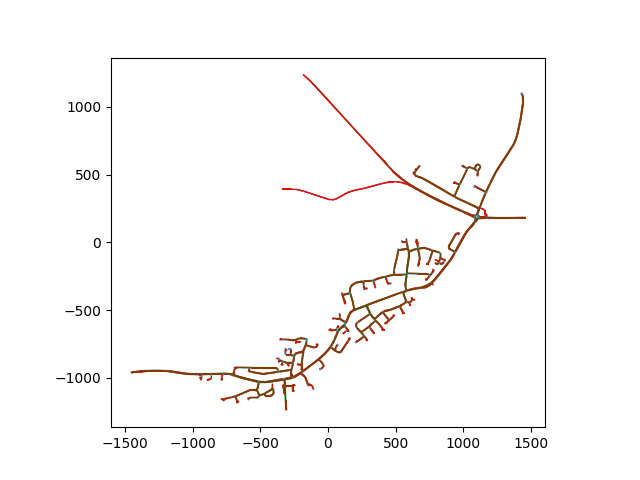

In [441]:
removed_gdf = rotated_output_gdf[~(rotated_output_gdf.index.isin(indx_to_remove))]
fig,ax = plt.subplots()
#rotated_output_gdf.plot(ax = ax)
removed_gdf.plot(ax = ax, color = 'red')
survey_union_offset_gdf.plot(ax = ax, color = 'blue', alpha = 0.5)
survey_gdf.plot(ax = ax, color = 'green', alpha = 0.1)

In [442]:
geom = survey_union_offset_gdf.iloc[0].geometry

lines = [getattr(row, "geometry") for row in removed_gdf.itertuples()]
splitters = unary_union(lines)
network = unary_union([geom.boundary, splitters])
cell_polys = [
    poly
    for poly in polygonize(network)
    if geom.contains(poly.representative_point())
]
print(len(lines), "splitters ->", len(cell_polys), "cells")
cell_gdf = gpd.GeoDataFrame({'geometry': cell_polys}, crs=survey_union_offset_gdf.crs)
cell_gdf = cell_gdf.reset_index().rename(columns={'index': 'cell_idx'})

1669 splitters -> 1656 cells


In [ ]:
cell_gdf['area'].describe()

KeyError: 'area'